In [1]:
%config InteractiveShell.ast_node_interactivity='last_expr_or_assign'  # always print last expr.
%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Traffic Dataset

There are two files for each fold, the data file and the labels file. We have split the 440 time series between train and test folds, but you are of course free to merge them to consider a different cross validation setting.
- The PEMS_train textfile has 263 lines. Each line describes a time-series provided as a matrix. The matrix syntax is that of Matlab, e.g. [ a b ; c d] is the matrix with row vectors [a b] and [c d] in that order. Each matrix describes the different occupancies rates (963 lines, one for each station/detector) sampled every 10 minutes during the day (144 columns).
- The PEMS_trainlabel text describes, for each day of measurements described above, the day of the week on which the data was sampled, namely an integer between 1 (Mon.) and 7 (Sun.).

- PEMS_test and PEMS_testlabels are formatted in the same way, except that there are 173 test instances.

- The permutation that I used to shuffle the dataset is given in the randperm file. If you need to rearrange the data so that it follows the calendar order, you should merge train and test samples and reorder them using the inverse permutation of randperm.

In [2]:
from tsdm.datasets import BaseDataset

In [3]:
class Traffic(BaseDataset):
    url: str = r"https://archive.ics.uci.edu/ml/machine-learning-databases/00204/"
    info_url: str = r"https://archive.ics.uci.edu/ml/datasets/PEMS-SF"


Traffic.download()

--2021-10-06 09:32:29--  https://archive.ics.uci.edu/ml/machine-learning-databases/00204/
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 517 [text/html]
Saving to: ‘/home/rscholz/.tsdm/rawdata/Traffic/index.html’

     0K                                                       100% 6,08M=0s

Last-modified header missing -- time-stamps turned off.
2021-10-06 09:32:30 (6,08 MB/s) - ‘/home/rscholz/.tsdm/rawdata/Traffic/index.html’ saved [517/517]

Loading robots.txt; please ignore errors.
--2021-10-06 09:32:30--  https://archive.ics.uci.edu/robots.txt
Reusing existing connection to archive.ics.uci.edu:443.
HTTP request sent, awaiting response... 404 Not Found
2021-10-06 09:32:30 ERROR 404: Not Found.

--2021-10-06 09:32:30--  https://archive.ics.uci.edu/ml/machine-learning-databases/00204/PEMS-SF.zip
Reusing existing connecti

In [4]:
from pathlib import Path
from zipfile import ZipFile

import numpy as np
import pandas
from pandas import DataFrame, read_csv, read_hdf, Series
from scipy.io import loadmat

from io import StringIO

In [5]:
use_true = True

# The true anomalies were found by iteratively adding them 1 by one,
# Each time checking when the first date was when
# labels[invperm].map(weekdays) didn't match with dates.day_name()
true_dates = pandas.date_range("2008-01-01", "2009-03-26", freq="d", name="day")
true_anomalies = pandas.DatetimeIndex(
    {
        "2008-01-01": "New Year’s Day",
        "2008-01-21": "Martin Luther King Jr. Day",
        "2008-02-18": "Washington’s Birthday",
        "2008-03-09": "anomaly + wrong year",
        "2008-05-26": "Memorial Day",
        "2008-07-04": "Independence Day",
        "2008-09-01": "Labor Day",
        "2008-10-20": "???",
        "2008-11-17": "???",
        "2008-12-07": "???",
        "2009-02-23": "???",
    }
)
true_weekdays = {
    "1": "Sunday",
    "2": "Monday",
    "3": "Tuesday",
    "4": "Wednesday",
    "5": "Thursday",
    "6": "Friday",
    "7": "Saturday",
}


false_dates = pandas.date_range("2008-01-01", "2009-03-30", freq="d", name="day")
false_anomalies = pandas.DatetimeIndex(
    {
        "Jan. 1, 2008": "New Year’s Day",
        "Jan. 21, 2008": "Martin Luther King Jr. Day",
        "Feb. 18, 2008": "Washington’s Birthday",
        "Mar. 9, 2008": "Anomaly day",
        "May 26, 2008": "Memorial Day",
        "Jul. 4, 2008": "Independence Day",
        "Sep. 1, 2008": "Labor Day",
        "Oct. 13, 2008": "Columbus Day",
        "Nov. 11, 2008": "Veterans Day",
        "Nov. 27, 2008": "Thanksgiving",
        "Dec. 25, 2008": "Christmas Day",
        "Jan. 1, 2009": "New Year’s Day",
        "Jan. 19, 2009": "Martin Luther King Jr. Day",
        "Feb. 16, 2009": "Washington’s Birthday",
        "Mar. 8, 2009": "Anomaly day",
    }
)
false_weekdays = {
    "1": "Monday",
    "2": "Tuesday",
    "3": "Wednesday",
    "4": "Thursday",
    "5": "Friday",
    "6": "Saturday",
    "7": "Sunday",
}

dates = true_dates if use_true else false_dates
anomalies = true_anomalies if use_true else false_anomalies
weekdays = true_weekdays if use_true else false_weekdays

mask = dates.isin(anomalies)
assert sum(mask) == len(anomalies)
dates = dates[~mask]

DatetimeIndex(['2008-01-02', '2008-01-03', '2008-01-04', '2008-01-05',
               '2008-01-06', '2008-01-07', '2008-01-08', '2008-01-09',
               '2008-01-10', '2008-01-11',
               ...
               '2009-03-17', '2009-03-18', '2009-03-19', '2009-03-20',
               '2009-03-21', '2009-03-22', '2009-03-23', '2009-03-24',
               '2009-03-25', '2009-03-26'],
              dtype='datetime64[ns]', name='day', length=440, freq=None)

In [6]:
timestamps = pandas.timedelta_range("0:00:00", "23:59:59", freq="10min", name="time")
assert len(timestamps) == 144
timestamps

TimedeltaIndex(['0 days 00:00:00', '0 days 00:10:00', '0 days 00:20:00',
                '0 days 00:30:00', '0 days 00:40:00', '0 days 00:50:00',
                '0 days 01:00:00', '0 days 01:10:00', '0 days 01:20:00',
                '0 days 01:30:00',
                ...
                '0 days 22:20:00', '0 days 22:30:00', '0 days 22:40:00',
                '0 days 22:50:00', '0 days 23:00:00', '0 days 23:10:00',
                '0 days 23:20:00', '0 days 23:30:00', '0 days 23:40:00',
                '0 days 23:50:00'],
               dtype='timedelta64[ns]', name='time', length=144, freq='10T')

In [7]:
def _reformat(s: str, replacements: dict) -> str:
    """Replaces substrings with replacments from dict.

    https://stackoverflow.com/a/64500851/9318372
    """
    *_, s = (s := s.replace(c, r) for c, r in replacements.items())
    return s

In [8]:
rawdata_file = Traffic.rawdata_path.joinpath("PEMS-SF.zip")

with ZipFile(rawdata_file) as files:
    with files.open("stations_list") as file:
        content = file.read().decode("utf8")
        content = _reformat(content, {"[": "", "]": "", " ": "\n"})
        stations = pandas.read_csv(
            StringIO(content),
            names=["station"],
            dtype="category",
            squeeze=True,
        )

    with files.open("randperm") as file:
        content = file.read().decode("utf8")
        content = _reformat(content, {"[": "", "]": "", " ": "\n"})
        randperm = pandas.read_csv(
            StringIO(content),
            names=["randperm"],
            dtype="uint16",
            squeeze=True,
        )
        randperm = randperm - 1  # we use 0-based indexing
        invperm = randperm.copy().argsort()
        invperm.name = "invperm"
        assert (randperm[invperm] == np.arange(len(randperm))).all()

    # Shuffle dates according to permutation the authors applied
    shuffled_dates = dates[randperm]

    with files.open("PEMS_trainlabels") as file:
        content = file.read().decode("utf8")
        content = _reformat(content, {"[": "", "]": "\n", " ": "\n"})
        PEMS_trainlabels = pandas.read_csv(
            StringIO(content),
            names=["labels"],
            dtype="category",
            squeeze=True,
        )
        train_dates = shuffled_dates[: len(PEMS_trainlabels)]
        PEMS_trainlabels.index = train_dates

    # Check that the labels match with the actual weekdays
    assert (
        PEMS_trainlabels.index.day_name() == PEMS_trainlabels.values.map(weekdays)
    ).all(), "Labels do not match with dates!"

    with files.open("PEMS_testlabels") as file:
        content = file.read().decode("utf8")
        content = _reformat(content, {"[": "", "]": "", " ": "\n"})
        PEMS_testlabels = pandas.read_csv(
            StringIO(content),
            names=["labels"],
            dtype="category",
            squeeze=True,
        )
        test_dates = shuffled_dates[len(PEMS_trainlabels) :]
        PEMS_testlabels.index = test_dates

    assert (
        PEMS_testlabels.index.day_name() == PEMS_testlabels.values.map(weekdays)
    ).all(), "Labels do not match with dates!"
    assert (
        PEMS_trainlabels.dtype == PEMS_testlabels.dtype
    ), "Train and test have different labels!"
    PEMS_labels = pandas.concat([PEMS_trainlabels, PEMS_testlabels]).rename("labels")

    with files.open("PEMS_train") as file:
        _PEMS_train = []
        for line in file:
            line = line.decode("utf8")
            line = _reformat(line, {"[": "", "]": "", ";": "\n", " ": ","})
            df = pandas.read_csv(
                StringIO(line),
                header=None,
            )
            df = DataFrame(df.values, index=stations, columns=timestamps)
            # df.index = stations
            # df.columns = timestamps
            _PEMS_train.append(df.T)
        PEMS_train = pandas.concat(_PEMS_train, keys=train_dates)

    with files.open("PEMS_test") as file:
        _PEMS_test = []
        for line in file:
            line = line.decode("utf8")
            line = _reformat(line, {"[": "", "]": "", ";": "\n", " ": ","})
            df = pandas.read_csv(
                StringIO(line),
                header=None,
            )
            df = DataFrame(df.values, index=stations, columns=timestamps)
            # df.index = stations
            # df.columns = timestamps
            _PEMS_test.append(df.T)
        PEMS_test = pandas.concat(_PEMS_test, keys=test_dates)

PEMS_labels = pandas.concat([PEMS_trainlabels, PEMS_testlabels])

mismatches = PEMS_labels[invperm].map(weekdays) != dates.day_name()
assert len(dates[mismatches]) == 0, "Mismatches in label and date weekday!"
PEMS = pandas.concat([PEMS_train, PEMS_test])

station                     400000  400001  400009  400010  400015  400017  \
day        time                                                              
2008-09-09 0 days 00:00:00  0.0154  0.0054  0.0164  0.0079  0.0059  0.0138   
           0 days 00:10:00  0.0085  0.0051  0.0127  0.0062  0.0051  0.0125   
           0 days 00:20:00  0.0099  0.0056  0.0172  0.0068  0.0053  0.0116   
           0 days 00:30:00  0.0108  0.0045  0.0126  0.0072  0.0058  0.0131   
           0 days 00:40:00  0.0100  0.0037  0.0185  0.0048  0.0063  0.0099   
...                            ...     ...     ...     ...     ...     ...   
2008-03-28 0 days 23:10:00  0.0334  0.0189  0.0467  0.0279  0.0099  0.0344   
           0 days 23:20:00  0.0267  0.0173  0.0505  0.0219  0.0140  0.0399   
           0 days 23:30:00  0.0251  0.0143  0.0554  0.0152  0.0120  0.0275   
           0 days 23:40:00  0.0235  0.0123  0.0552  0.0197  0.0134  0.0234   
           0 days 23:50:00  0.0251  0.0121  0.0431  0.0125  0.0103  0.0250   

station                     400025  400026  400027  400030  ...  402081  \
day        time                                             ...           
2008-09-09 0 days 00:00:00  0.0111  0.0156  0.0154  0.0080  ...  0.0027   
           0 days 00:10:00  0.0099  0.0175  0.0134  0.0067  ...  0.0010   
           0 days 00:20:00  0.0105  0.0157  0.0112  0.0065  ...  0.0010   
           0 days 00:30:00  0.0073  0.0146  0.0128  0.0040  ...  0.0014   
           0 days 00:40:00  0.0061  0.0157  0.0123  0.0064  ...  0.0013   
...                            ...     ...     ...     ...  ...     ...   
2008-03-28 0 days 23:10:00  0.0159  0.0453  0.0433  0.0371  ...  0.0192   
           0 days 23:20:00  0.0151  0.0520  0.0462  0.0332  ...  0.0193   
           0 days 23:30:00  0.0128  0.0413  0.0419  0.0341  ...  0.0184   
           0 days 23:40:00  0.0095  0.0389  0.0431  0.0343  ...  0.0198   
           0 days 23:50:00  0.0120  0.0334  0.0331  0.0325  ...  0.0159   

station                     402082  402083  402084  402085  402086  402087  \
day        time                                                              
2008-09-09 0 days 00:00:00  0.0142  0.0125  0.0261  0.0182  0.0208  0.0196   
           0 days 00:10:00  0.0074  0.0113  0.0228  0.0131  0.0115  0.0156   
           0 days 00:20:00  0.0072  0.0113  0.0246  0.0216  0.0137  0.0201   
           0 days 00:30:00  0.0081  0.0119  0.0232  0.0311  0.0124  0.0188   
           0 days 00:40:00  0.0055  0.0084  0.0225  0.0139  0.0119  0.0180   
...                            ...     ...     ...     ...     ...     ...   
2008-03-28 0 days 23:10:00  0.0046  0.0152  0.0201  0.0270  0.0136  0.0382   
           0 days 23:20:00  0.0058  0.0142  0.0292  0.0274  0.0475  0.0294   
           0 days 23:30:00  0.0045  0.0146  0.0178  0.0271  0.0367  0.0326   
           0 days 23:40:00  0.0061  0.0135  0.0207  0.0278  0.0316  0.0473   
           0 days 23:50:00  0.0032  0.0092  0.0159  0.0259  0.0200  0.0336   

station                     402088  402089  402090  
day        time                                     
2008-09-09 0 days 00:00:00  0.0123  0.0150  0.0140  
           0 days 00:10:00  0.0065  0.0113  0.0183  
           0 days 00:20:00  0.0098  0.0141  0.0112  
           0 days 00:30:00  0.0077  0.0130  0.0107  
           0 days 00:40:00  0.0078  0.0155  0.0162  
...                            ...     ...     ...  
2008-03-28 0 days 23:10:00  0.0317  0.0332  0.0405  
           0 days 23:20:00  0.0341  0.0285  0.0446  
           0 days 23:30:00  0.0292  0.0322  0.0394  
           0 days 23:40:00  0.0297  0.0406  0.0406  
           0 days 23:50:00  0.0244  0.0297  0.0363  

[63360 rows x 963 columns]


There are two files for each fold, the data file and the labels file. We have split the 440 time series between train and test folds, but you are of course free to merge them to consider a different cross validation setting.
- The PEMS_train textfile has 263 lines. Each line describes a time-series provided as a matrix. The matrix syntax is that of Matlab, e.g. [ a b ; c d] is the matrix with row vectors [a b] and [c d] in that order. Each matrix describes the different occupancies rates (963 lines, one for each station/detector) sampled every 10 minutes during the day (144 columns).
- The PEMS_trainlabel text describes, for each day of measurements described above, the day of the week on which the data was sampled, namely an integer between 1 (Mon.) and 7 (Sun.).

- PEMS_test and PEMS_testlabels are formatted in the same way, except that there are 173 test instances.

- The permutation that I used to shuffle the dataset is given in the randperm file. If you need to rearrange the data so that it follows the calendar order, you should merge train and test samples and reorder them using the inverse permutation of randperm.

In [12]:
pandas.Series(PEMS_testlabels)

day
2008-12-24    4
2008-09-08    2
2008-06-07    7
2008-04-23    4
2009-02-10    3
             ..
2008-08-24    1
2008-02-05    3
2009-01-20    3
2008-09-05    6
2008-03-28    6
Name: labels, Length: 173, dtype: category
Categories (7, object): ['1', '2', '3', '4', '5', '6', '7']

In [9]:
PEMS_labels.reset_index().set_index("day").squeeze()

day
2008-09-09    3
2008-09-10    4
2009-03-17    3
2008-05-01    5
2009-01-25    1
             ..
2008-08-24    1
2008-02-05    3
2009-01-20    3
2008-09-05    6
2008-03-28    6
Name: labels, Length: 440, dtype: category
Categories (7, object): ['1', '2', '3', '4', '5', '6', '7']

## Example Plot

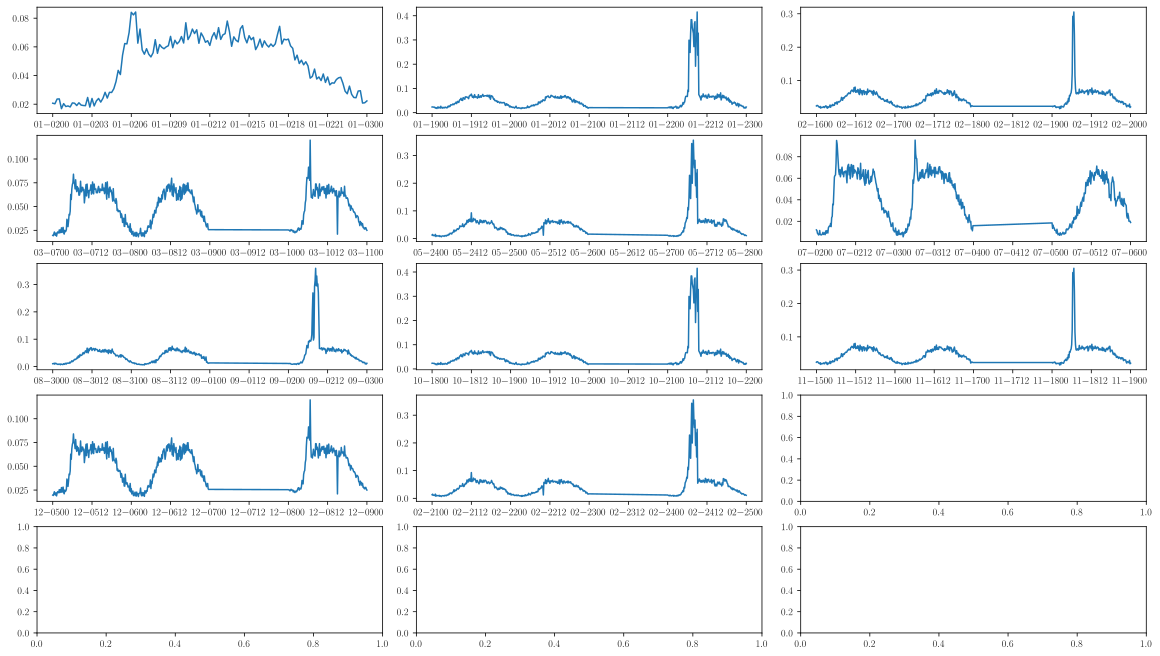

In [10]:
import matplotlib.pyplot as plt

station = PEMS.loc[dates]["400000"].reset_index()
station.index = station.day + station.time
station = station.drop(columns=["day", "time"])

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(16, 9), constrained_layout=True)

# visualize around anomalies
for anomalie, ax in zip(anomalies, axes.flatten()):
    start = pandas.Timestamp(anomalie) - pandas.Timedelta("2d")
    stop = pandas.Timestamp(anomalie) + pandas.Timedelta("2d")
    ts = station.loc[start:stop]
    ax.plot(ts.index.to_numpy(), ts.values)